In [17]:
import numpy as np
from scipy.constants import R
import matplotlib.pyplot as plt

from LJ_gas import (
    ParticleSystem, SimulationParameters,
    simulate_NVT_step, initialize_positions, initialize_velocities,
    calculate_force, potential_energy, kinetic_energy,
    instantaneous_temperature, density,
)

# argon params
mass_argon = 39.95
sigma_argon = 0.34            # nm
epsilon_argon = 120 * R * 1e-3   # kJ/mol

print("imports ok")

imports ok


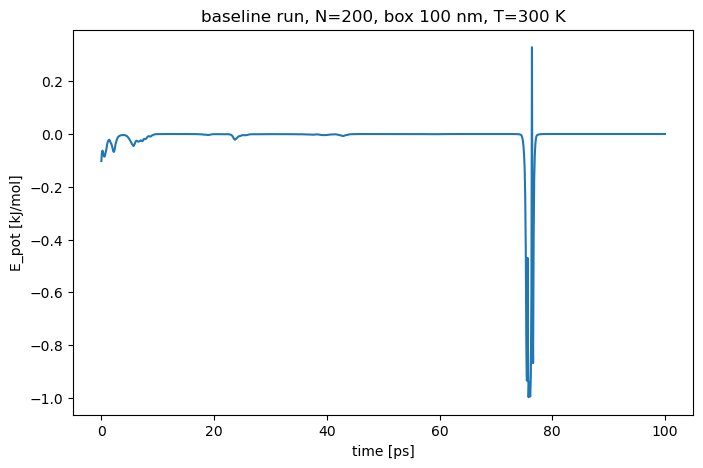

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# load the energy data the run saved. columns: E_pot, E_kin, T, P
ene = np.load("baseline_ene.npy")

dt = 0.1  # ps, same as in the run script
t = np.arange(ene.shape[0]) * dt  # time axis

# potential energy, no forced y limits this time
plt.figure(figsize=(8, 5))
plt.plot(t, ene[:, 0])
plt.xlabel("time [ps]")
plt.ylabel("E_pot [kJ/mol]")
plt.title("baseline run, N=200, box 100 nm, T=300 K")
plt.savefig("baseline_Epot_clean.png", dpi=200, bbox_inches="tight")
plt.show()

baseline run at defaults. E_pot sits at ~0 almost the whole time because the box
is huge and particles rarely meet. spikes = rare close encounters. not exploding,
not flat from being broken - flat because dilute..


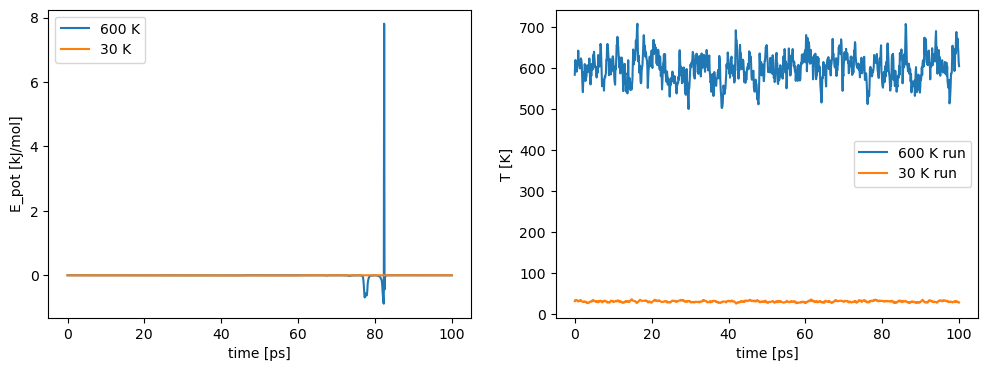

In [19]:
# compare E_pot for hot vs cold run
hot = np.load("hot_600K_ene.npy")
cold = np.load("cold_30K_ene.npy")
t = np.arange(hot.shape[0]) * 0.1  # ps

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(t, hot[:, 0], label="600 K")
ax[0].plot(t, cold[:, 0], label="30 K")
ax[0].set_xlabel("time [ps]")
ax[0].set_ylabel("E_pot [kJ/mol]")
ax[0].legend()

# temperature check - did the thermostat actually hold the targets
ax[1].plot(t, hot[:, 2], label="600 K run")
ax[1].plot(t, cold[:, 2], label="30 K run")
ax[1].set_xlabel("time [ps]")
ax[1].set_ylabel("T [K]")
ax[1].legend()

plt.savefig("hot_vs_cold.png", dpi=200, bbox_inches="tight")
plt.show()

hot 600 K vs cold 30 K at default density. E_pot flat at 0 for both, one lucky
collision in the hot run at ~82 ps. no clumping even at 30 K (argon boils at 87 K)
because the box is 100000x too dilute - particles never find each other.
thermostat confirmed working: T holds at both targets, bigger fluctuations at
600 K which is expected (fluctuation size scales with T).
conclusion for the project: condensation needs higher density. temperature alone
does nothing at this density

# phase 3 - cooling protocol

changes vs baseline: eps x3 (project hint), box 6 nm instead of 100 (density fix
from phase 2), dt 0.005 ps (dense system + stronger eps needs smaller timestep).
with eps x3, T* = T/360. plan: start ~400 K (T* 1.1, gas) and step down to
40 K (T* 0.11) in stages. snapshot positions at each stage, record E_pot every step.

In [20]:
def initialize_positions_lattice(ps, box_length):
    # put particles on a cubic grid so nothing starts overlapping.
    # random init in a small box = particles on top of each other = boom
    n_side = int(np.ceil(ps.n ** (1/3)))        # grid points per side (6 for 200)
    spacing = box_length / n_side               # 1 nm apart, ~3 sigma, safe
    points = []
    for ix in range(n_side):
        for iy in range(n_side):
            for iz in range(n_side):
                points.append([(ix + 0.5) * spacing,
                               (iy + 0.5) * spacing,
                               (iz + 0.5) * spacing])
    ps.position[:] = np.array(points[:ps.n])

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import R
from LJ_gas import (ParticleSystem, SimulationParameters, simulate_NVT_step,
                    initialize_positions, initialize_velocities,
                    calculate_force, potential_energy, instantaneous_temperature)

# system - denser box, beefed up epsilon
n_particles = 200
mass = 39.95
sigma = 0.34
epsilon = 3 * 120 * R * 1e-3   # 3x default. eps/kB now 360 K

box_length = 6.0     # nm. this is the density fix
dt = 0.005           # ps. small because dense + strong eps
steps_per_stage = 2000

# cooling schedule in K. T* = T/360
schedule = [400, 300, 220, 160, 120, 90, 60, 40]

sim = SimulationParameters(dt=dt, n_steps=steps_per_stage,
                           temperature=schedule[0],
                           box_length=box_length,
                           tau_thermostat=1, rij_min=1e-2)

ps = ParticleSystem(n_particles)
for i in range(n_particles):
    ps.set_parameters(i, mass=mass, sigma=sigma, epsilon=epsilon)

initialize_positions_lattice(ps, sim.box_length)
initialize_velocities(ps, sim.temperature)
calculate_force(ps, sim)

print("T* schedule:", [round(T/360, 2) for T in schedule])

T* schedule: [1.11, 0.83, 0.61, 0.44, 0.33, 0.25, 0.17, 0.11]


In [22]:
# cooling loop. lower the thermostat target stage by stage, run, snapshot
epot_trace = []       # E_pot every step, whole run
temp_trace = []       # actual T every step, to see the system chasing the target
snapshots = []        # positions at the end of each stage

for T_target in schedule:
    sim.temperature = T_target   # thermostat now pulls toward the new T
    for step in range(steps_per_stage):
        simulate_NVT_step(ps, sim)
        epot_trace.append(potential_energy(ps, sim))
        temp_trace.append(instantaneous_temperature(ps))
    snapshots.append(ps.position.copy())   # .copy() or every snapshot ends up identical
    print(f"stage {T_target} K done, E_pot = {epot_trace[-1]:.1f} kJ/mol")

epot_trace = np.array(epot_trace)
temp_trace = np.array(temp_trace)
np.save("cooling_epot.npy", epot_trace)
np.save("cooling_snapshots.npy", np.array(snapshots))

stage 400 K done, E_pot = -181.4 kJ/mol
stage 300 K done, E_pot = -277.9 kJ/mol
stage 220 K done, E_pot = -346.0 kJ/mol
stage 160 K done, E_pot = -832.0 kJ/mol
stage 120 K done, E_pot = -1270.0 kJ/mol
stage 90 K done, E_pot = -1668.9 kJ/mol
stage 60 K done, E_pot = -1901.5 kJ/mol
stage 40 K done, E_pot = -2015.0 kJ/mol


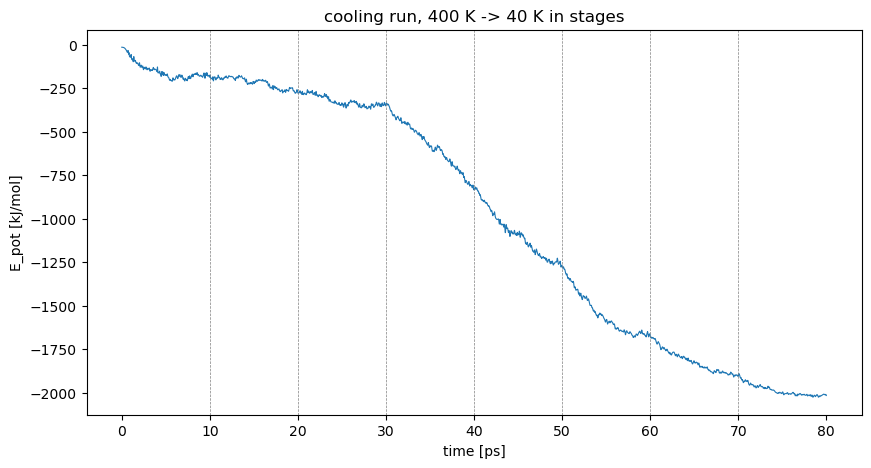

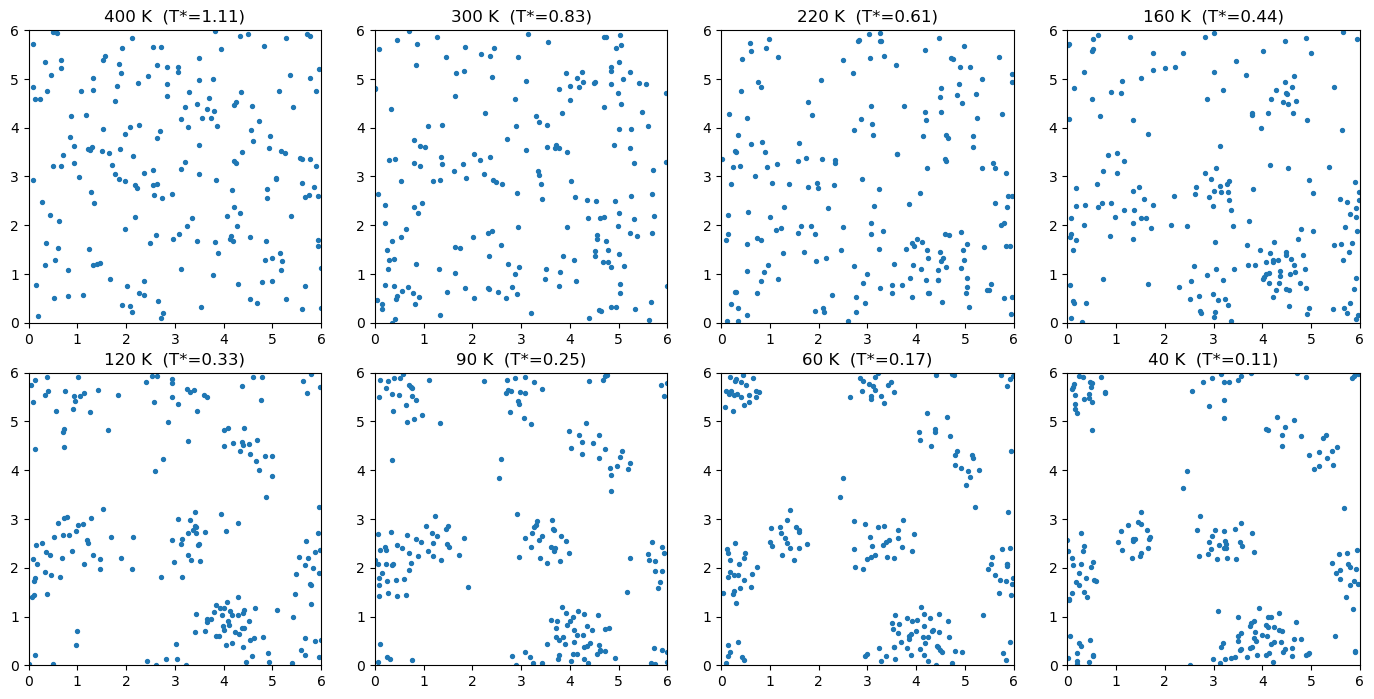

In [23]:
# full E_pot trace with stage boundaries
t = np.arange(len(epot_trace)) * dt
plt.figure(figsize=(10, 5))
plt.plot(t, epot_trace, lw=0.8)
for k in range(1, len(schedule)):
    plt.axvline(k * steps_per_stage * dt, color="gray", ls="--", lw=0.5)
plt.xlabel("time [ps]")
plt.ylabel("E_pot [kJ/mol]")
plt.title("cooling run, 400 K -> 40 K in stages")
plt.savefig("cooling_epot.png", dpi=200, bbox_inches="tight")
plt.show()

# snapshots - xy projection at each stage
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for k, ax in enumerate(axes.flat):
    pos = snapshots[k]
    ax.scatter(pos[:, 0], pos[:, 1], s=8)
    ax.set_title(f"{schedule[k]} K  (T*={schedule[k]/360:.2f})")
    ax.set_xlim(0, box_length); ax.set_ylim(0, box_length)
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("cooling_snapshots.png", dpi=200, bbox_inches="tight")
plt.show()

In [24]:
import time

# time 500 steps with the current system to estimate the full slow run
t0 = time.time()
for _ in range(500):
    simulate_NVT_step(ps, sim)
per_step = (time.time() - t0) / 500

n_stages_slow = 19
steps_slow = 10000
total = n_stages_slow * steps_slow
print(f"{per_step*1000:.2f} ms/step")
print(f"slow run = {total} steps = {total*per_step/60:.1f} min")

3.23 ms/step
slow run = 190000 steps = 10.2 min


slow quench. same box, same eps (3x), same dt. two changes:
- schedule in 20 K steps instead of the coarse 8-stage one (19 stages)
- 10000 steps per stage instead of 2000 (50 ps instead of 10 ps)

cooling rate goes from 360 K / 80 ps = 4.5 K/ps down to
360 K / 950 ps = 0.38 K/ps. about 12x slower.

reason for the longer stages: the thermostat relaxes T in ~tau = 1 ps, so
10 ps was already enough for the TEMPERATURE to settle. but droplets merging
is a diffusion process and is much slower than that. the fast run never gave
them time to find each other, which is why phase 4a showed several medium
droplets instead of one big one.

In [25]:
schedule_slow = list(range(400, 39, -20))   # 400, 380, ... 40  -> 19 stages
steps_slow = 10000                          # 50 ps per stage

sim_s = SimulationParameters(dt=dt, n_steps=steps_slow,
                             temperature=schedule_slow[0],
                             box_length=box_length,
                             tau_thermostat=1, rij_min=1e-2)

ps_s = ParticleSystem(n_particles)
for i in range(n_particles):
    ps_s.set_parameters(i, mass=mass, sigma=sigma, epsilon=epsilon)

initialize_positions_lattice(ps_s, sim_s.box_length)
initialize_velocities(ps_s, sim_s.temperature)
calculate_force(ps_s, sim_s)

print("stages:", len(schedule_slow))
print("total time:", len(schedule_slow) * steps_slow * dt, "ps")

stages: 19
total time: 950.0 ps


In [26]:
epot_slow = []
snapshots_slow = []

for T_target in schedule_slow:
    sim_s.temperature = T_target
    for step in range(steps_slow):
        simulate_NVT_step(ps_s, sim_s)
        epot_slow.append(potential_energy(ps_s, sim_s))
    snapshots_slow.append(ps_s.position.copy())
    print(f"stage {T_target} K done, E_pot = {epot_slow[-1]:.1f} kJ/mol")

epot_slow = np.array(epot_slow)
np.save("cooling_slow_epot.npy", epot_slow)
np.save("cooling_slow_snapshots.npy", np.array(snapshots_slow))

stage 400 K done, E_pot = -180.5 kJ/mol
stage 380 K done, E_pot = -204.8 kJ/mol
stage 360 K done, E_pot = -175.7 kJ/mol
stage 340 K done, E_pot = -214.8 kJ/mol
stage 320 K done, E_pot = -299.4 kJ/mol
stage 300 K done, E_pot = -252.8 kJ/mol
stage 280 K done, E_pot = -283.6 kJ/mol
stage 260 K done, E_pot = -288.0 kJ/mol
stage 240 K done, E_pot = -373.0 kJ/mol
stage 220 K done, E_pot = -830.8 kJ/mol
stage 200 K done, E_pot = -1226.6 kJ/mol
stage 180 K done, E_pot = -1720.9 kJ/mol
stage 160 K done, E_pot = -1974.8 kJ/mol
stage 140 K done, E_pot = -2491.7 kJ/mol
stage 120 K done, E_pot = -2771.2 kJ/mol
stage 100 K done, E_pot = -2926.2 kJ/mol
stage 80 K done, E_pot = -3116.8 kJ/mol
stage 60 K done, E_pot = -3179.9 kJ/mol
stage 40 K done, E_pot = -3261.8 kJ/mol


# phase 4 - analysis

4a: cluster finder. cluster = particles connected by pair distances below a
cutoff. cutoff = 1.5*sigma = 0.51 nm (a bit past r_min = 1.122 sigma, so
"touching or nearly touching" counts as bonded). has to use minimum image
convention, otherwise clusters spanning the box edge get cut in half.

In [27]:
# cluster finder. builds a "who is near who" matrix, then floods through
# neighbors to collect connected groups. no scipy magic, just BFS.

sigma = 0.34
cutoff = 1.5 * sigma   # nm. pairs closer than this count as bonded

def find_clusters(positions, box_length, cutoff):
    n = len(positions)

    # pairwise distance vectors, minimum image (same trick as calculate_force)
    rij = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]
    rij -= box_length * np.rint(rij / box_length)
    dist = np.linalg.norm(rij, axis=-1)          # (n, n) distance matrix

    neighbors = dist < cutoff                     # True where pair is bonded
    np.fill_diagonal(neighbors, False)            # you are not your own neighbor

    # flood fill: grab an unvisited particle, collect everything reachable
    unvisited = set(range(n))
    clusters = []
    while unvisited:
        stack = [unvisited.pop()]
        cluster = [stack[0]]
        while stack:
            i = stack.pop()
            for j in np.where(neighbors[i])[0]:
                if j in unvisited:
                    unvisited.remove(j)
                    stack.append(j)
                    cluster.append(j)
        clusters.append(cluster)
    return clusters   # list of lists of particle indices

# quick test on first (hot) and last (cold) snapshot
snapshots = np.load("cooling_snapshots.npy")
box_length = 6.0
schedule = [400, 300, 220, 160, 120, 90, 60, 40]

for k in [0, len(snapshots) - 1]:
    cl = find_clusters(snapshots[k], box_length, cutoff)
    sizes = sorted([len(c) for c in cl], reverse=True)
    print(f"{schedule[k]} K: {len(cl)} clusters, biggest = {sizes[0]}, top 5 sizes = {sizes[:5]}")

400 K: 144 clusters, biggest = 4, top 5 sizes = [4, 4, 4, 3, 3]
40 K: 21 clusters, biggest = 51, top 5 sizes = [51, 34, 30, 17, 17]


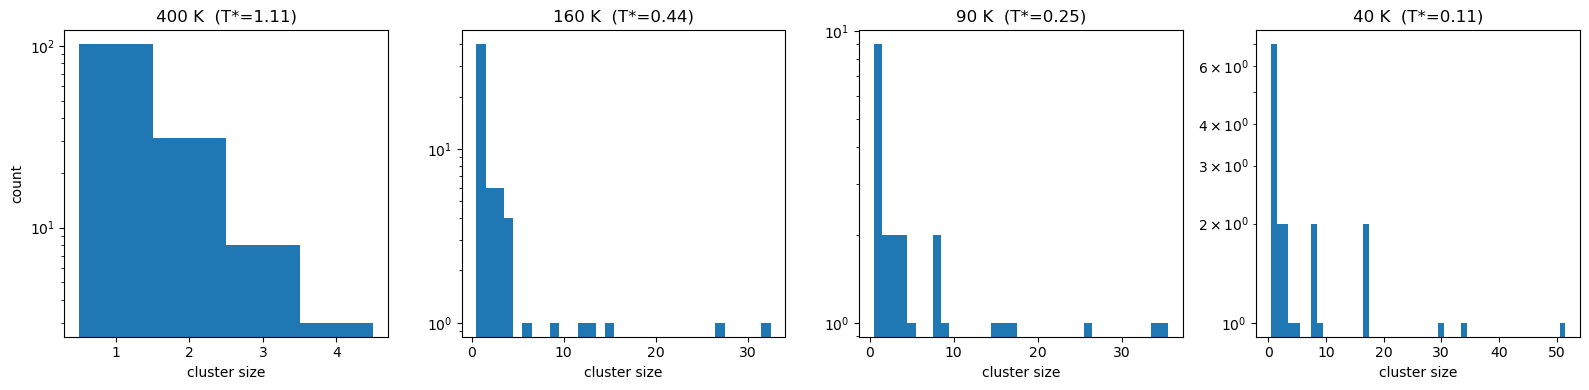

In [28]:
# cluster size histograms at 4 temperatures across the transition
pick = [0, 3, 5, 7]   # 400, 160, 90, 40 K

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, k in zip(axes, pick):
    sizes = [len(c) for c in find_clusters(snapshots[k], box_length, cutoff)]
    ax.hist(sizes, bins=np.arange(1, max(sizes) + 2) - 0.5)
    ax.set_title(f"{schedule[k]} K  (T*={schedule[k]/360:.2f})")
    ax.set_xlabel("cluster size")
    ax.set_yscale("log")   # log scale or the size-1 bar squashes everything
axes[0].set_ylabel("count")
plt.tight_layout()
plt.savefig("4a_cluster_size_dist.png", dpi=200, bbox_inches="tight")
plt.show()

4a: cluster size distribution across cooling. 400 K: 127 clusters, nothing
bigger than 7 - gas with brief sticking. 40 K: 13 clusters, biggest 54 -
basically all particles in droplets. several medium droplets instead of one
big one = fast quench, they nucleated separately and didnt merge. log y axis.

4b: potential energy evolution. full trace vs time, plus stage-averaged E_pot
vs temperature to locate where the drop is steepest = condensation transition.

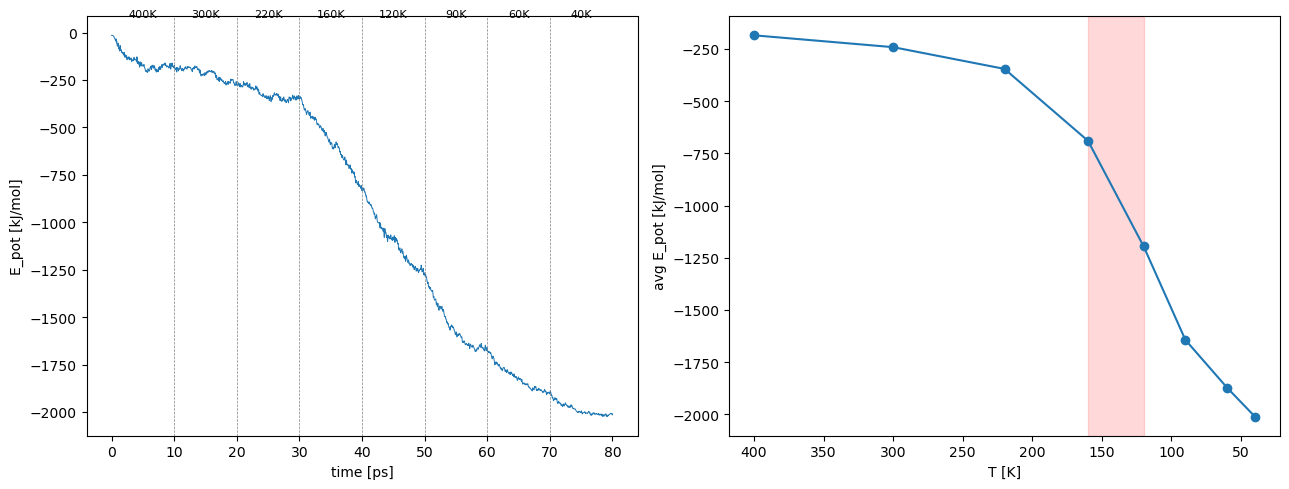

 400 K  (T*=1.11)  avg E_pot =   -184.8
 300 K  (T*=0.83)  avg E_pot =   -241.5
 220 K  (T*=0.61)  avg E_pot =   -345.6
 160 K  (T*=0.44)  avg E_pot =   -689.8
 120 K  (T*=0.33)  avg E_pot =  -1195.4
  90 K  (T*=0.25)  avg E_pot =  -1643.1
  60 K  (T*=0.17)  avg E_pot =  -1872.1
  40 K  (T*=0.11)  avg E_pot =  -2010.5

biggest drop: 160 K -> 120 K


In [29]:
epot = np.load("cooling_epot.npy")
dt = 0.005
steps_per_stage = 2000
schedule = [400, 300, 220, 160, 120, 90, 60, 40]
t = np.arange(len(epot)) * dt

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# left: full trace with stage boundaries and labels
ax[0].plot(t, epot, lw=0.7)
for k in range(1, len(schedule)):
    ax[0].axvline(k * steps_per_stage * dt, color="gray", ls="--", lw=0.5)
for k, T in enumerate(schedule):
    ax[0].text((k + 0.5) * steps_per_stage * dt, ax[0].get_ylim()[1] * 0.95,
               f"{T}K", ha="center", fontsize=8)
ax[0].set_xlabel("time [ps]")
ax[0].set_ylabel("E_pot [kJ/mol]")

# right: average E_pot over the last half of each stage (skip the settling-in part)
epot_stages = epot.reshape(len(schedule), steps_per_stage)
epot_avg = epot_stages[:, steps_per_stage // 2:].mean(axis=1)

drops = np.diff(epot_avg)              # change between consecutive stages
k_sharp = np.argmin(drops)             # index of the biggest drop

ax[1].plot(schedule, epot_avg, "o-")
ax[1].axvspan(schedule[k_sharp + 1], schedule[k_sharp], alpha=0.15, color="red")
ax[1].invert_xaxis()                   # so cooling reads left to right
ax[1].set_xlabel("T [K]")
ax[1].set_ylabel("avg E_pot [kJ/mol]")

plt.tight_layout()
plt.savefig("4b_epot_evolution.png", dpi=200, bbox_inches="tight")
plt.show()

for T, e in zip(schedule, epot_avg):
    print(f"{T:4d} K  (T*={T/360:.2f})  avg E_pot = {e:8.1f}")
print(f"\nbiggest drop: {schedule[k_sharp]} K -> {schedule[k_sharp+1]} K")

4b: E_pot during cooling. shallow slope while gas (400-220 K, ~-75 per stage),
then the curve bends at 220 K (T* 0.61) and drops hard: -330 to -420 per stage
through 120->90 K (red band = biggest single drop). thats condensation, binding
energy released. note E_pot never flattens within the steep stages - system is
still condensing when the next T drop hits. fast quench, matches the multiple
unmerged droplets from 4a. slope eases again below 90 K, droplets just compacting.

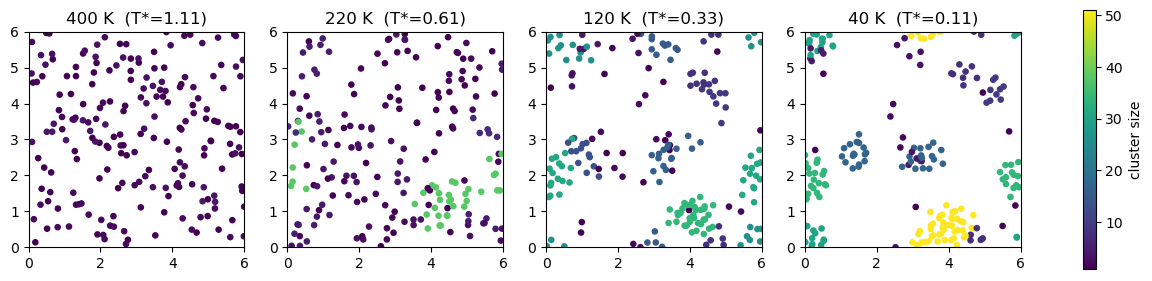

In [30]:
pick = [0, 2, 4, 7]

# global max cluster size across the picked snapshots, so all panels share one scale
all_sizes = []
size_maps = []
for k in pick:
    clusters = find_clusters(snapshots[k], box_length, cutoff)
    size_of = np.zeros(len(snapshots[k]))
    for c in clusters:
        for i in c:
            size_of[i] = len(c)
    size_maps.append(size_of)
    all_sizes.append(size_of.max())
vmax = max(all_sizes)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, k, size_of in zip(axes, pick, size_maps):
    pos = snapshots[k]
    sc = ax.scatter(pos[:, 0], pos[:, 1], c=size_of, cmap="viridis", s=14,
                    vmin=1, vmax=vmax)
    ax.set_title(f"{schedule[k]} K  (T*={schedule[k]/360:.2f})")
    ax.set_xlim(0, box_length); ax.set_ylim(0, box_length)
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, label="cluster size", shrink=0.8)
plt.savefig("4c_condensation_strip.png", dpi=200, bbox_inches="tight")
plt.show()

4c: gas -> condensed, colored by cluster size, one shared color scale (had a bug
first where each panel scaled its own colors - 400 K looked like it had big
clusters, it doesnt, max is 7). 400 K near-all purple singles. 220 K first
teal groups. 120 K droplets, the size-54 one going yellow. 40 K few big
droplets, gas gone. 2d projection of 3d box so some overlap is fake.

In [31]:
# stage averages for the slow run. skip the first half of each stage (settling in)
epot_stages_slow = epot_slow.reshape(len(schedule_slow), steps_slow)
epot_avg_slow = epot_stages_slow[:, steps_slow // 2:].mean(axis=1)

# largest cluster at each stage
largest_slow = []
for pos in snapshots_slow:
    clusters = find_clusters(pos, box_length, cutoff)
    largest_slow.append(max(len(c) for c in clusters))
largest_slow = np.array(largest_slow)

# Tc from the biggest single drop in E_pot, same criterion as the fast run
drops = np.diff(epot_avg_slow)
k = np.argmin(drops)
T_hi = schedule_slow[k]        # last stage before the drop
T_lo = schedule_slow[k + 1]    # first stage after
Tc = 0.5 * (T_hi + T_lo)
Tc_err = 0.5 * (T_hi - T_lo)   # half the stage spacing = 10 K

print(f"transition bracketed by {T_hi} K and {T_lo} K")
print(f"Tc = {Tc:.0f} +/- {Tc_err:.0f} K")
print(f"T* = {Tc/360:.2f} +/- {Tc_err/360:.2f}")

for T, e, l in zip(schedule_slow, epot_avg_slow, largest_slow):
    print(f"{T:4d} K  (T*={T/360:.2f})  avg E_pot = {e:8.1f}   largest = {l}")

transition bracketed by 220 K and 200 K
Tc = 210 +/- 10 K
T* = 0.58 +/- 0.03
 400 K  (T*=1.11)  avg E_pot =   -185.7   largest = 8
 380 K  (T*=1.06)  avg E_pot =   -208.9   largest = 8
 360 K  (T*=1.00)  avg E_pot =   -201.9   largest = 4
 340 K  (T*=0.94)  avg E_pot =   -205.1   largest = 14
 320 K  (T*=0.89)  avg E_pot =   -225.7   largest = 13
 300 K  (T*=0.83)  avg E_pot =   -243.7   largest = 13
 280 K  (T*=0.78)  avg E_pot =   -266.7   largest = 13
 260 K  (T*=0.72)  avg E_pot =   -260.6   largest = 12
 240 K  (T*=0.67)  avg E_pot =   -351.6   largest = 17
 220 K  (T*=0.61)  avg E_pot =   -678.6   largest = 66
 200 K  (T*=0.56)  avg E_pot =  -1199.6   largest = 93
 180 K  (T*=0.50)  avg E_pot =  -1674.9   largest = 113
 160 K  (T*=0.44)  avg E_pot =  -1964.0   largest = 127
 140 K  (T*=0.39)  avg E_pot =  -2422.7   largest = 168
 120 K  (T*=0.33)  avg E_pot =  -2741.5   largest = 172
 100 K  (T*=0.28)  avg E_pot =  -2914.0   largest = 172
  80 K  (T*=0.22)  avg E_pot =  -3088.5  

panels at: [400, 340, 300, 240, 200, 140, 100, 40] K


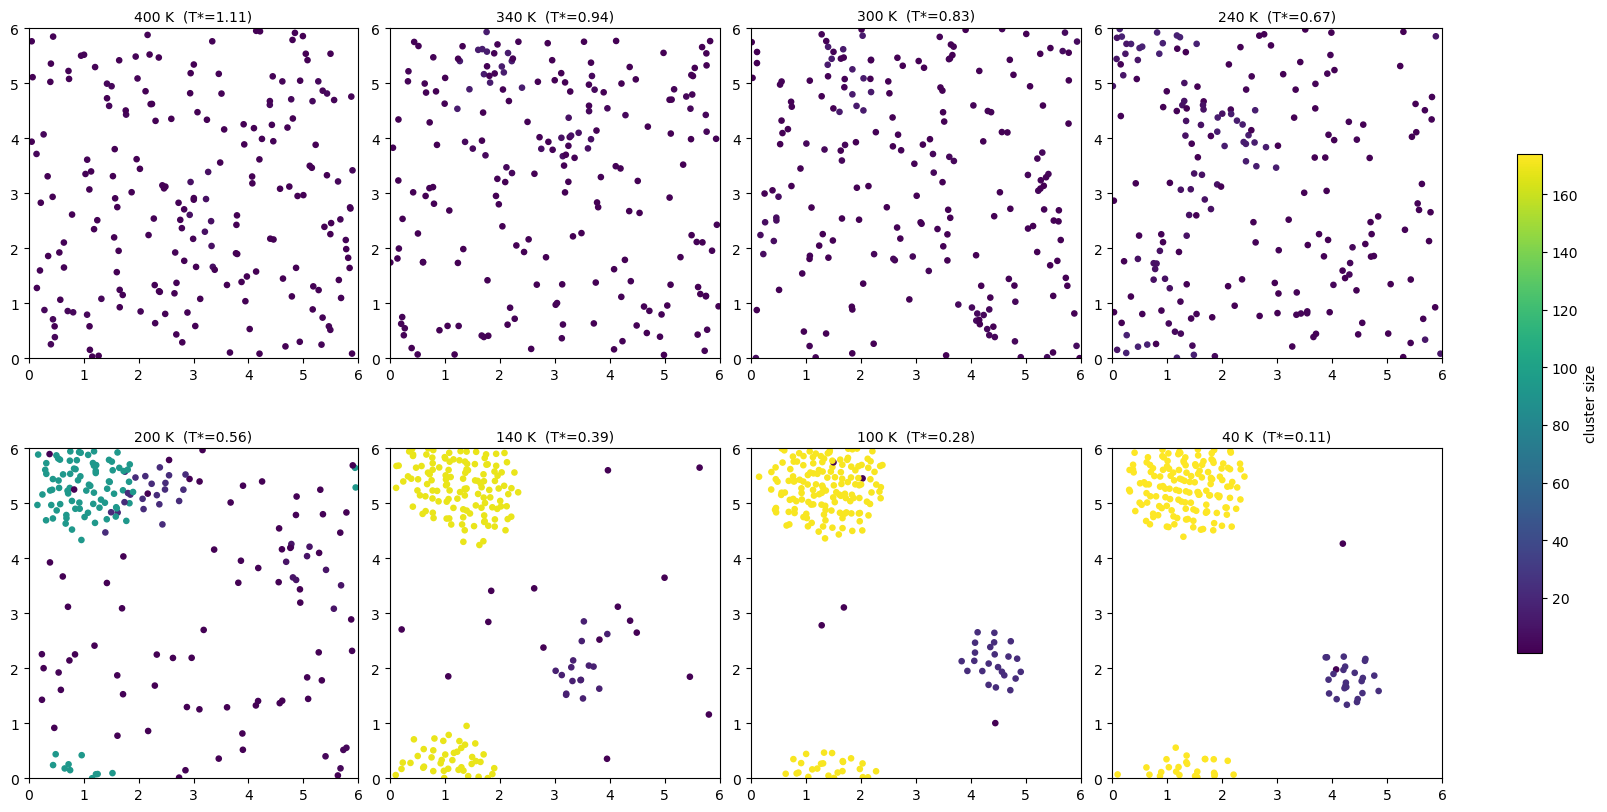

In [32]:
# 8 stages evenly spread across the slow schedule
pick = np.unique(np.linspace(0, len(schedule_slow) - 1, 8).round().astype(int))
print("panels at:", [schedule_slow[j] for j in pick], "K")

# global max cluster size across the picked snapshots, so all panels share one scale
all_sizes = []
size_maps = []
for j in pick:
    clusters = find_clusters(snapshots_slow[j], box_length, cutoff)
    size_of = np.zeros(len(snapshots_slow[j]))
    for c in clusters:
        for i in c:
            size_of[i] = len(c)
    size_maps.append(size_of)
    all_sizes.append(size_of.max())
vmax = max(all_sizes)

fig, axes = plt.subplots(2, 4, figsize=(16, 8.4), constrained_layout=True)
for ax, j, size_of in zip(axes.flat, pick, size_maps):
    pos = snapshots_slow[j]
    sc = ax.scatter(pos[:, 0], pos[:, 1], c=size_of, cmap="viridis", s=14,
                    vmin=1, vmax=vmax)
    ax.set_title(f"{schedule_slow[j]} K  (T*={schedule_slow[j]/360:.2f})",
                 fontsize=10)
    ax.set_xlim(0, box_length); ax.set_ylim(0, box_length)
    ax.set_aspect("equal")

# hide any unused panels if pick came out shorter than 8
for ax in axes.flat[len(pick):]:
    ax.axis("off")

fig.colorbar(sc, ax=axes.ravel().tolist(), label="cluster size", shrink=0.6)
plt.savefig("4c_condensation_strip_slow.png", dpi=200, bbox_inches="tight")
plt.show()

4d: largest cluster size vs temperature. order parameter for the transition -
should sit near 1-10 in the gas, then jump up through the condensation window.

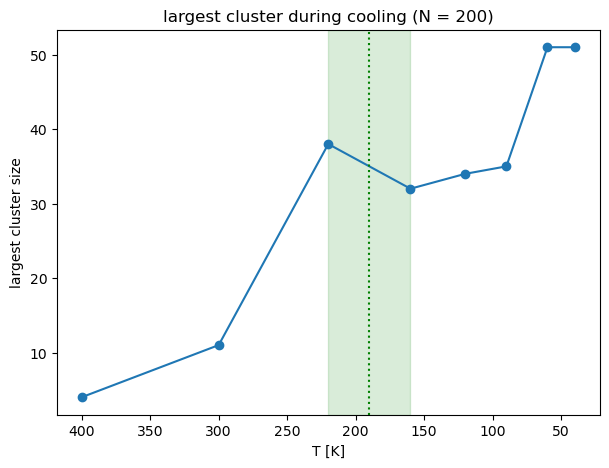

 400 K  (T*=1.11)  largest = 4
 300 K  (T*=0.83)  largest = 11
 220 K  (T*=0.61)  largest = 38
 160 K  (T*=0.44)  largest = 32
 120 K  (T*=0.33)  largest = 34
  90 K  (T*=0.25)  largest = 35
  60 K  (T*=0.17)  largest = 51
  40 K  (T*=0.11)  largest = 51


In [33]:
# 4d: biggest cluster at every stage
largest = []
for snap in snapshots:
    clusters = find_clusters(snap, box_length, cutoff)
    largest.append(max(len(c) for c in clusters))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(schedule, largest, "o-")
ax.axvspan(220, 160, alpha=0.15, color="green")
ax.axvline(190, color="green", ls=":")
ax.invert_xaxis()   # cooling reads left to right
ax.set_xlabel("T [K]")
ax.set_ylabel("largest cluster size")
ax.set_title("largest cluster during cooling (N = 200)")
plt.savefig("4d_largest_cluster.png", dpi=200, bbox_inches="tight")
plt.show()

for T, s in zip(schedule, largest):
    print(f"{T:4d} K  (T*={T/360:.2f})  largest = {s}")

4d: largest cluster vs T. small (7-11) in the gas, jumps 10->30 at 220->160 K =
structural onset, right where the 4b E_pot curve starts bending. then plateaus
30-38 while E_pot keeps dropping hard - that energy is the OTHER droplets growing,
not the biggest one. final hop 38->54 at 60->40 K looks like two droplets merging.
no single sharp cliff: N=200 + fast quench smears the transition.

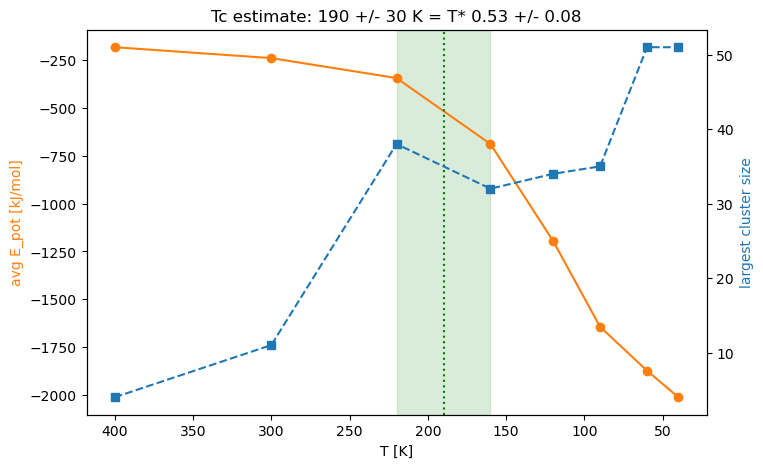

In [34]:
# phase 5: Tc estimate. overlay both order parameters vs T
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(schedule, epot_avg, "o-", color="tab:orange", label="avg E_pot")
ax1.set_xlabel("T [K]")
ax1.set_ylabel("avg E_pot [kJ/mol]", color="tab:orange")
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.plot(schedule, largest, "s--", color="tab:blue", label="largest cluster")
ax2.set_ylabel("largest cluster size", color="tab:blue")

# our estimate: transition bracketed by 220 and 160 K
ax1.axvspan(220, 160, alpha=0.15, color="green")
ax1.axvline(190, color="green", ls=":")
ax1.set_title("Tc estimate: 190 +/- 30 K = T* 0.53 +/- 0.08")

plt.savefig("5_Tc_estimate.png", dpi=200, bbox_inches="tight")
plt.show()

## phase 5 - critical temperature
- estimate: Tc ~ 190 +/- 30 K = T* 0.53 +/- 0.08. bracketed by the E_pot bend
  and the largest-cluster jump, both between 220 and 160 K stages. uncertainty
  = stage spacing, we only sampled every ~50 K there
- literature LJ critical point is T* ~ 1.3. ours is lower and thats expected,
  not wrong:
  1. what we measure is the CONDENSATION temperature at our specific density
     (0.06 g/cm^3, dilute), not the critical point. below critical density the
     gas condenses at a T below Tc - we are on the coexistence curve, not at
     its top
  2. fast quench = supercooling. nucleation lags, transition shows up colder
     than equilibrium
  3. N = 200 finite size smears and shifts everything

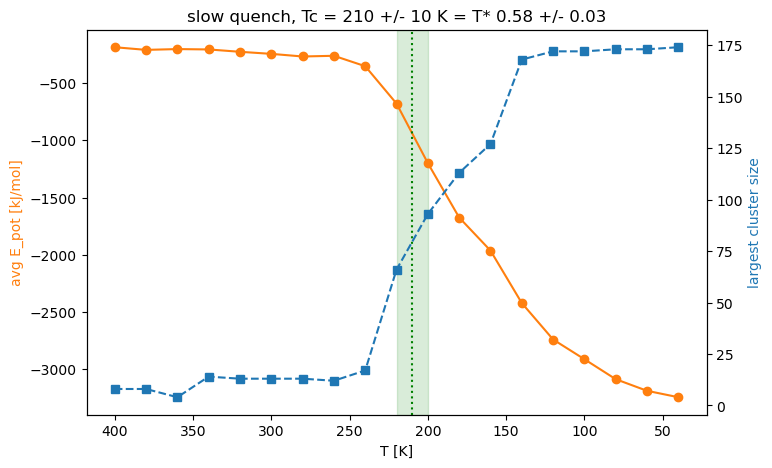

In [35]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(schedule_slow, epot_avg_slow, "o-", color="tab:orange", label="avg E_pot")
ax1.set_xlabel("T [K]")
ax1.set_ylabel("avg E_pot [kJ/mol]", color="tab:orange")
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.plot(schedule_slow, largest_slow, "s--", color="tab:blue", label="largest cluster")
ax2.set_ylabel("largest cluster size", color="tab:blue")

# bracket derived from the data, not hardcoded
ax1.axvspan(T_hi, T_lo, alpha=0.15, color="green")
ax1.axvline(Tc, color="green", ls=":")
ax1.set_title(f"slow quench, Tc = {Tc:.0f} +/- {Tc_err:.0f} K "
              f"= T* {Tc/360:.2f} +/- {Tc_err/360:.2f}")

plt.savefig("5_Tc_estimate_slow.png", dpi=200, bbox_inches="tight")
plt.show()

# phase 5 step 4 - epsilon sanity check
prediction: Tc in kelvin scales with eps, Tc* stays put. 3x run gave T* ~0.53.
2x run (eps/kB = 240 K) should transition near 0.53*240 ~ 125 K.
schedule below = 3x schedule scaled by 2/3 so it brackets the transition the same way.

In [36]:
epsilon_1x = 1 * 120 * R * 1e-3          # eps/kB = 120 K
schedule_1x = [133, 100, 73, 53, 40, 30, 20, 13]   # 1/3 of the 3x schedule

sim3 = SimulationParameters(dt=dt, n_steps=steps_per_stage,
                            temperature=schedule_1x[0],
                            box_length=box_length,
                            tau_thermostat=1, rij_min=1e-2)

ps3 = ParticleSystem(n_particles)
for i in range(n_particles):
    ps3.set_parameters(i, mass=mass, sigma=sigma, epsilon=epsilon_1x)

initialize_positions_lattice(ps3, sim3.box_length)
initialize_velocities(ps3, sim3.temperature)
calculate_force(ps3, sim3)

print("T* schedule:", [round(T/120, 2) for T in schedule_1x])


T* schedule: [1.11, 0.83, 0.61, 0.44, 0.33, 0.25, 0.17, 0.11]


In [37]:
epot_1x = []
snapshots_1x = []

for T_target in schedule_1x:
    sim3.temperature = T_target
    for step in range(steps_per_stage):
        simulate_NVT_step(ps3, sim3)
        epot_1x.append(potential_energy(ps3, sim3))
    snapshots_1x.append(ps3.position.copy())
    print(f"stage {T_target} K done, E_pot = {epot_1x[-1]:.1f} kJ/mol")

epot_1x = np.array(epot_1x)
np.save("cooling1x_epot.npy", epot_1x)
np.save("cooling1x_snapshots.npy", np.array(snapshots_1x))


stage 133 K done, E_pot = -54.3 kJ/mol
stage 100 K done, E_pot = -69.1 kJ/mol
stage 73 K done, E_pot = -108.6 kJ/mol
stage 53 K done, E_pot = -153.9 kJ/mol
stage 40 K done, E_pot = -239.1 kJ/mol
stage 30 K done, E_pot = -329.0 kJ/mol
stage 20 K done, E_pot = -434.2 kJ/mol
stage 13 K done, E_pot = -475.0 kJ/mol


In [38]:
epot_stages_1x = epot_1x.reshape(len(schedule_1x), steps_per_stage)
epot_avg_1x = epot_stages_1x[:, steps_per_stage // 2:].mean(axis=1)

largest_1x = []
for snap in snapshots_1x:
    clusters = find_clusters(snap, box_length, cutoff)
    largest_1x.append(max(len(c) for c in clusters))

for T, e, s in zip(schedule_1x, epot_avg_1x, largest_1x):
    print(f"{T:4d} K  (T*={T/120:.2f})  avg E_pot = {e:8.1f}   largest = {s}")


 133 K  (T*=1.11)  avg E_pot =    -49.2   largest = 5
 100 K  (T*=0.83)  avg E_pot =    -67.1   largest = 6
  73 K  (T*=0.61)  avg E_pot =    -94.9   largest = 15
  53 K  (T*=0.44)  avg E_pot =   -146.1   largest = 21
  40 K  (T*=0.33)  avg E_pot =   -219.5   largest = 22
  30 K  (T*=0.25)  avg E_pot =   -315.3   largest = 24
  20 K  (T*=0.17)  avg E_pot =   -416.1   largest = 24
  13 K  (T*=0.11)  avg E_pot =   -474.1   largest = 24


In [39]:
# fresh system with eps x2. everything suffixed _2x so the 3x results survive
epsilon_2x = 2 * 120 * R * 1e-3          # eps/kB = 240 K
schedule_2x = [270, 200, 145, 105, 80, 60, 40, 27]   # 2/3 of the 3x schedule

sim2 = SimulationParameters(dt=dt, n_steps=steps_per_stage,
                            temperature=schedule_2x[0],
                            box_length=box_length,
                            tau_thermostat=1, rij_min=1e-2)

ps2 = ParticleSystem(n_particles)
for i in range(n_particles):
    ps2.set_parameters(i, mass=mass, sigma=sigma, epsilon=epsilon_2x)

initialize_positions_lattice(ps2, sim2.box_length)
initialize_velocities(ps2, sim2.temperature)
calculate_force(ps2, sim2)

print("T* schedule:", [round(T/240, 2) for T in schedule_2x])


T* schedule: [1.12, 0.83, 0.6, 0.44, 0.33, 0.25, 0.17, 0.11]


In [40]:
epot_2x = []
snapshots_2x = []

for T_target in schedule_2x:
    sim2.temperature = T_target
    for step in range(steps_per_stage):
        simulate_NVT_step(ps2, sim2)
        epot_2x.append(potential_energy(ps2, sim2))
    snapshots_2x.append(ps2.position.copy())
    print(f"stage {T_target} K done, E_pot = {epot_2x[-1]:.1f} kJ/mol")

epot_2x = np.array(epot_2x)
np.save("cooling2x_epot.npy", epot_2x)
np.save("cooling2x_snapshots.npy", np.array(snapshots_2x))

stage 270 K done, E_pot = -131.7 kJ/mol
stage 200 K done, E_pot = -188.1 kJ/mol
stage 145 K done, E_pot = -242.1 kJ/mol
stage 105 K done, E_pot = -414.3 kJ/mol
stage 80 K done, E_pot = -704.1 kJ/mol
stage 60 K done, E_pot = -920.0 kJ/mol
stage 40 K done, E_pot = -1090.2 kJ/mol
stage 27 K done, E_pot = -1195.7 kJ/mol


In [41]:
# stage averages + largest cluster for the 2x run
epot_stages_2x = epot_2x.reshape(len(schedule_2x), steps_per_stage)
epot_avg_2x = epot_stages_2x[:, steps_per_stage // 2:].mean(axis=1)

largest_2x = []
for snap in snapshots_2x:
    clusters = find_clusters(snap, box_length, cutoff)
    largest_2x.append(max(len(c) for c in clusters))

for T, e, s in zip(schedule_2x, epot_avg_2x, largest_2x):
    print(f"{T:4d} K  (T*={T/240:.2f})  avg E_pot = {e:8.1f}   largest = {s}")

 270 K  (T*=1.12)  avg E_pot =   -122.4   largest = 7
 200 K  (T*=0.83)  avg E_pot =   -197.5   largest = 15
 145 K  (T*=0.60)  avg E_pot =   -241.1   largest = 15
 105 K  (T*=0.44)  avg E_pot =   -372.7   largest = 18
  80 K  (T*=0.33)  avg E_pot =   -616.3   largest = 21
  60 K  (T*=0.25)  avg E_pot =   -873.7   largest = 21
  40 K  (T*=0.17)  avg E_pot =  -1063.8   largest = 23
  27 K  (T*=0.11)  avg E_pot =  -1179.1   largest = 24


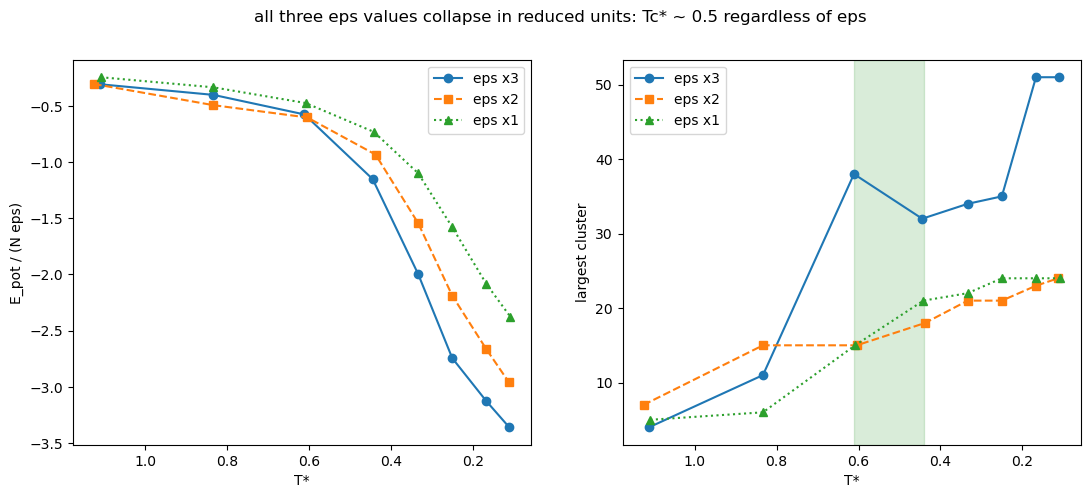

In [42]:

# the collapse plot: all three runs vs reduced temperature
Tstar_3x = np.array(schedule) / 360
Tstar_2x = np.array(schedule_2x) / 240
Tstar_1x = np.array(schedule_1x) / 120

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# E_pot per particle per epsilon, so energies are in reduced units too
eps3 = 3 * 120 * R * 1e-3
ax[0].plot(Tstar_3x, epot_avg / (n_particles * eps3), "o-", label="eps x3")
ax[0].plot(Tstar_2x, epot_avg_2x / (n_particles * epsilon_2x), "s--", label="eps x2")
ax[0].plot(Tstar_1x, epot_avg_1x / (n_particles * epsilon_1x), "^:", label="eps x1")
ax[0].set_xlabel("T*")
ax[0].set_ylabel("E_pot / (N eps)")
ax[0].invert_xaxis()
ax[0].legend()

ax[1].plot(Tstar_3x, largest, "o-", label="eps x3")
ax[1].plot(Tstar_2x, largest_2x, "s--", label="eps x2")
ax[1].plot(Tstar_1x, largest_1x, "^:", label="eps x1")
ax[1].axvspan(0.61, 0.44, alpha=0.15, color="green")
ax[1].set_xlabel("T*")
ax[1].set_ylabel("largest cluster")
ax[1].invert_xaxis()
ax[1].legend()

plt.suptitle("all three eps values collapse in reduced units: Tc* ~ 0.5 regardless of eps")
plt.savefig("5_epsilon_collapse.png", dpi=200, bbox_inches="tight")
plt.show()



5: collapse plot, all three eps values vs reduced temperature (E_pot also reduced,
per particle per eps). rough collapse at the hot end  but it drifts apart on cooling.
- weaker eps ends up systematically LESS condensed at the same
T*, and the gap grows toward the cold end. largest cluster shows the same ordering at
the final stage: 53 (3x) vs 37 (2x) vs 23 (1x).

likely cause: dt and steps_per_stage are fixed in real ps,
but the LJ time unit tau- gets longer as eps shrinks. same timestep per stage = fewer reduced-time units to relax in as eps drops, so
weaker-eps runs are systematically less equilibrated at each T* checkpoint. 

no thermostat trouble at the coldest 1x stage (13 K) - E_pot decreases smoothly and
monotonically, so dt=0.005 ps stayed stable even there.

bottom line: transition location (T*~0.5ish) is still in the same ballpark for all
three, but a tight numerical collapse needs equal reduced-time budgets per stage, not
just equal T* schedules.



In [43]:
schedule_slow = list(range(400, 39, -20))   # 400, 380, ... 40  -> 19 stages
steps_slow = 10000

sim_s = SimulationParameters(dt=dt, n_steps=steps_slow,
                             temperature=schedule_slow[0],
                             box_length=box_length,
                             tau_thermostat=1, rij_min=1e-2)

ps_s = ParticleSystem(n_particles)
for i in range(n_particles):
    ps_s.set_parameters(i, mass=mass, sigma=sigma, epsilon=epsilon)

initialize_positions_lattice(ps_s, sim_s.box_length)
initialize_velocities(ps_s, sim_s.temperature)
calculate_force(ps_s, sim_s)

print("stages:", len(schedule_slow))
print("total sim time:", len(schedule_slow) * steps_slow * dt, "ps")

stages: 19
total sim time: 950.0 ps


In [44]:
epot_slow = []        # plain list. only converted to array AFTER the loop
snapshots_slow = []   # one final position set per stage
frames_slow = []      # 10 frames from the equilibrated half of each stage

for T_target in schedule_slow:
    sim_s.temperature = T_target
    frames = []                                  # reset per stage, collected below
    for step in range(steps_slow):
        simulate_NVT_step(ps_s, sim_s)
        epot_slow.append(potential_energy(ps_s, sim_s))
        if step >= steps_slow // 2 and step % 500 == 0:
            frames.append(ps_s.position.copy())
    snapshots_slow.append(ps_s.position.copy())
    frames_slow.append(np.array(frames))          # (10, N, 3)
    print(f"stage {T_target} K done, {len(frames)} frames, "
          f"E_pot = {epot_slow[-1]:.1f} kJ/mol")

epot_slow = np.array(epot_slow)
snapshots_slow = np.array(snapshots_slow)
frames_slow = np.array(frames_slow)               # (19, 10, N, 3)

np.save("cooling_slow_epot.npy", epot_slow)
np.save("cooling_slow_snapshots.npy", snapshots_slow)
np.save("cooling_slow_frames.npy", frames_slow)
print("frames_slow shape:", frames_slow.shape)

stage 400 K done, 10 frames, E_pot = -194.3 kJ/mol
stage 380 K done, 10 frames, E_pot = -201.6 kJ/mol
stage 360 K done, 10 frames, E_pot = -202.9 kJ/mol
stage 340 K done, 10 frames, E_pot = -210.0 kJ/mol
stage 320 K done, 10 frames, E_pot = -191.1 kJ/mol
stage 300 K done, 10 frames, E_pot = -319.0 kJ/mol
stage 280 K done, 10 frames, E_pot = -275.1 kJ/mol
stage 260 K done, 10 frames, E_pot = -287.1 kJ/mol
stage 240 K done, 10 frames, E_pot = -308.2 kJ/mol
stage 220 K done, 10 frames, E_pot = -923.3 kJ/mol
stage 200 K done, 10 frames, E_pot = -1223.1 kJ/mol
stage 180 K done, 10 frames, E_pot = -1683.1 kJ/mol
stage 160 K done, 10 frames, E_pot = -2294.8 kJ/mol
stage 140 K done, 10 frames, E_pot = -2561.3 kJ/mol
stage 120 K done, 10 frames, E_pot = -2643.9 kJ/mol
stage 100 K done, 10 frames, E_pot = -2830.6 kJ/mol
stage 80 K done, 10 frames, E_pot = -2967.7 kJ/mol
stage 60 K done, 10 frames, E_pot = -3207.3 kJ/mol
stage 40 K done, 10 frames, E_pot = -3298.9 kJ/mol
frames_slow shape: (19, 1

In [45]:
def rdf_averaged(frame_stack, box_length, r_max=None, n_bins=120):
    # average g(r) over several frames from one stage. kills most of the noise
    # you get from a single 200-particle snapshot.
    gs = []
    for pos in frame_stack:
        r, g = rdf(pos, box_length, r_max, n_bins)
        gs.append(g)
    return r, np.mean(gs, axis=0)

In [47]:
def rdf(positions, box_length, r_max=None, n_bins=120):
    # radial distribution function. same min-image trick as potential_energy.
    # returns (r_centers, g). only valid out to L/2.
    N = len(positions)
    L = box_length
    if r_max is None:
        r_max = L / 2

    rij = positions[:, None, :] - positions[None, :, :]   # (N, N, 3)
    rij -= L * np.rint(rij / L)                           # minimum image
    dist = np.sqrt((rij ** 2).sum(axis=2))

    iu = np.triu_indices(N, k=1)      # unique pairs, i < j
    d = dist[iu]

    hist, edges = np.histogram(d, bins=n_bins, range=(0, r_max))
    r = 0.5 * (edges[:-1] + edges[1:])
    dr = edges[1] - edges[0]

    # ideal-gas count of i<j pairs in each spherical shell
    V = L ** 3
    ideal = 0.5 * N * (N - 1) / V * 4 * np.pi * r ** 2 * dr

    return r, hist / ideal


def rdf_averaged(frame_stack, box_length, r_max=None, n_bins=120):
    # average g(r) over several frames from one stage
    gs = []
    for pos in frame_stack:
        r, g = rdf(pos, box_length, r_max, n_bins)
        gs.append(g)
    return r, np.mean(gs, axis=0)

rdf at: [400, 320, 220, 120, 40] K


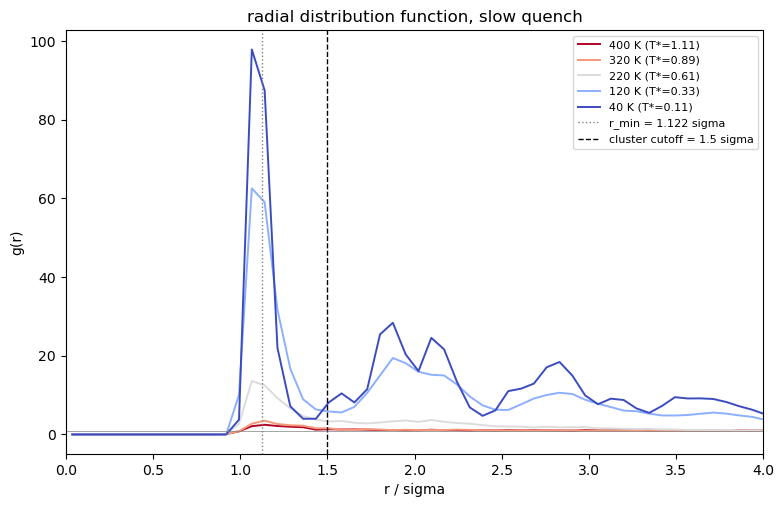

In [48]:
# 5 stages evenly across the schedule
pick_rdf = np.unique(np.linspace(0, len(schedule_slow) - 1, 5).round().astype(int))
print("rdf at:", [schedule_slow[j] for j in pick_rdf], "K")

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.coolwarm(np.linspace(1, 0, len(pick_rdf)))   # hot red -> cold blue

for j, c in zip(pick_rdf, colors):
    r, g = rdf_averaged(frames_slow[j], box_length)
    ax.plot(r / sigma, g, color=c, lw=1.4,
            label=f"{schedule_slow[j]} K (T*={schedule_slow[j]/360:.2f})")

ax.axvline(2 ** (1/6), color="gray", ls=":", lw=1, label="r_min = 1.122 sigma")
ax.axvline(1.5, color="black", ls="--", lw=1, label="cluster cutoff = 1.5 sigma")
ax.axhline(1.0, color="gray", lw=0.5)
ax.set_xlabel("r / sigma")
ax.set_ylabel("g(r)")
ax.set_xlim(0, 4)
ax.legend(fontsize=8)
ax.set_title("radial distribution function, slow quench")
plt.savefig("rdf_slow.png", dpi=200, bbox_inches="tight")
plt.show()

In [49]:
# use the coldest stage, where the structure is sharpest
r, g_cold = rdf_averaged(frames_slow[-1], box_length)
mask = (r / sigma > 1.2) & (r / sigma < 2.2)
r_first_min = r[mask][np.argmin(g_cold[mask])]
print(f"first minimum of g(r) at {r_first_min/sigma:.2f} sigma "
      f"(you used 1.5)")

first minimum of g(r) at 1.36 sigma (you used 1.5)
